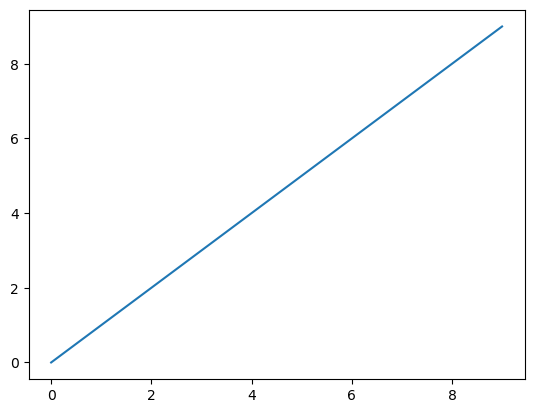

In [18]:
#package imports
#If using Jupyter locally, make sure you have pip installed saphires and any dependencies you need.
import saphires as saph
import matplotlib
import matplotlib.pyplot as plt
#matplotlib.use('Qt5Agg')
%matplotlib inline

import numpy as np
import os
from scipy.optimize import curve_fit

import pickle as pkl
from scipy.ndimage import gaussian_filter
import astropy



x = [0,1,2,3,4,5,6,7,8,9]
y = x
plt.plot(x, y)    #Testing out matplotlib inline to make sure this runs
print()
plt.show()

In [37]:
import os, glob
import numpy as np
from astropy.time import Time

star = 'MXDra'
#star = 'NRLib'


folder = os.path.join(r"C:\Users\Jonah\Astro\Stars\DATA\stars", star)

# 1) find all .p files whose basename starts with the same first letter as `star`
txtfiles = sorted(
    os.path.basename(f)
    for f in glob.glob(os.path.join(folder, "*.p"))
    if os.path.basename(f)[0].lower() == star[0].lower()
)

# 2) load the .dat into a true 2-D object array
dat_path  = os.path.join(folder, f"{star}_coude_head.dat")
#dat_path  = os.path.join(folder, f"{star}_nres_head.dat")
stardata  = np.genfromtxt(dat_path, delimiter=",", dtype=object)

# 3) slice out cols 5 and 6 and convert to float
BJD       = stardata[:, 5].astype(float)
BVCORR    = stardata[:, 6].astype(float)



# OPTIONAL: remove one entry (file + BJD + BVCORR)
#idx_to_remove = -2  # zero-based index of the row you want to drop
#txtfiles.pop(idx_to_remove)
#BJD    = np.delete(BJD,    idx_to_remove)
#BVCORR = np.delete(BVCORR, idx_to_remove)






# 4) convert BJD (TDB) → UTC ISO strings via Astropy
times = Time(BJD, format='jd', scale='tdb')
dates = times.utc.iso  # array of "YYYY-MM-DD HH:MM:SS.sss" strings in UTC

# string/table format for print check
header_fmt = "{:>3}  {:^32}  {:^25}    {:^12}    {:^16}"
row_fmt    = "{:>3}  {:<32}  {:<25}    {:>12}    {:>10}"

# 5) print header
print(header_fmt.format("Idx", "Filename", "Date (UTC)", "BJD", "BVCORR"))
print("-" * 100)

# 6) print each row
for i, (fn, date, bjd, bv) in enumerate(zip(txtfiles, dates, BJD, BVCORR), start=1):
    # truncate milliseconds to three decimal places:
    date_str = date  # already "YYYY-MM-DD HH:MM:SS.sss"
    print(row_fmt.format(i, fn, date_str, f"{bjd:.6f}", f"{bv:.3f}"))


path = os.path.join(folder, "")
print(f"\n{path}")

Idx              Filename                     Date (UTC)                BJD              BVCORR     
----------------------------------------------------------------------------------------------------
  1  MXDra_2020-05-10_0_4500_4.5.p     2020-05-10 04:28:19.227      2458979.687134       -15.122
  2  MXDra_2020-07-12_0_4500_4.5.p     2020-07-12 04:16:47.280      2459042.679126        -6.660
  3  MXDra_2021-01-31_0_4500_4.5.p     2021-01-31 11:05:32.438      2459245.962982         0.903
  4  MXDra_2021-03-30_0_4500_4.5.p     2021-03-30 07:19:04.591      2459303.805715       -12.325
  5  MXDra_2021-04-01_0_4500_4.5.p     2021-04-01 07:29:19.266      2459305.812829       -12.634
  6  MXDra_2021-04-23_0_4500_4.5.p     2021-04-23 06:53:04.059      2459327.787653       -14.874
  7  MXDra_2021-04-24_0_4500_4.5.p     2021-04-24 06:36:11.966      2459328.775939       -14.917
  8  MXDra_2021-05-30_0_4500_4.5.p     2021-05-30 04:36:20.964      2459364.692710       -13.985
  9  MXDra_2021-07-09_

In [38]:
#Constants
R_coude = 60000.0     #spectral resolution of the Coude.
c = (2.9979245*10**5)



In [39]:
BJD, BVCORR

(array([2458979.6871344 , 2459042.67912574, 2459245.96298174,
        2459303.80571501, 2459305.81282931, 2459327.78765329,
        2459328.77593926, 2459364.69271005, 2459404.62212169]),
 array([-15.122,  -6.66 ,   0.903, -12.325, -12.634, -14.874, -14.917,
        -13.985,  -7.372]))

In [40]:
Force_SB1 = True     #Force SB1 fit  (if asymmetry is impacting fit profile)
manual = False         #Force manual guessing, uses "guesses" array for p0 instead of automated guesses


guesses = [                                #force guess format, can take p0 prints from runs and edit

[0.011, 66.8, 29.572, 0.01, 40.305, 1.46, 0.0],
[0.011, 66.8, 29.572, 0.01, 40.305, 1.46, 0.0],


]


from pathlib import Path

outdir = Path("starBFs") / star            #broadening function plot output directory (changed to 'starBFs' or 'starBFs_asym')
outdir.mkdir(parents=True, exist_ok=True)

File 1
C:\Users\Jonah\Astro\Stars\DATA\stars\MXDra\MXDra_2020-05-10_0_4500_4.5.p
Number of Spectral Orders: 34
BJD: 2458979.6871344033
BVCORR -15.122
  Peak 1: center = 18.79 km/s, width = 46.35 km/s


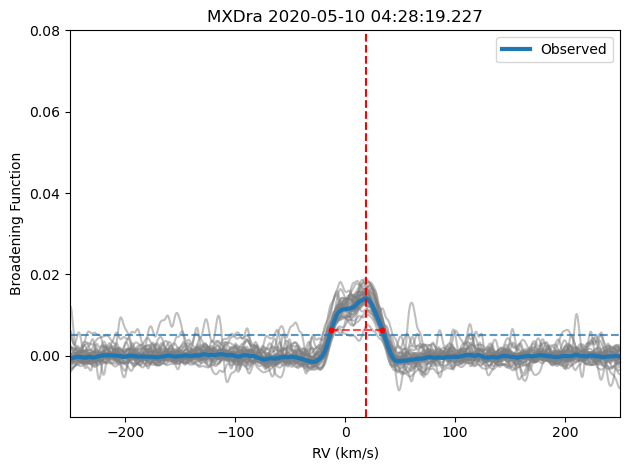

SB1
Amps: [0.01408164]
Centers: [18.79471714]
Widths: [46.34862158]
p0: [0.015, 18.795, 25.492, 0.0]

Vsini p0: [0.015489801112079442, 11.526723877313323, 25.491741869452657, 0.0]
  BVCORR: -15.122 km/s

      Results
  Primary RV (uncorrected): 11.53 + 0.18 - 0.18
  Primary RV (Barycenter Corrected): -3.6 + 0.18 - 0.18

  Primary vsini: 30.04 +/- 0.14 km/s
  
[(-3.595857548664792, 0.18478576496071675, 0.1807688246080552, 30.040590951019897, 0.13960208668107116, nan, nan, nan, nan, nan)]


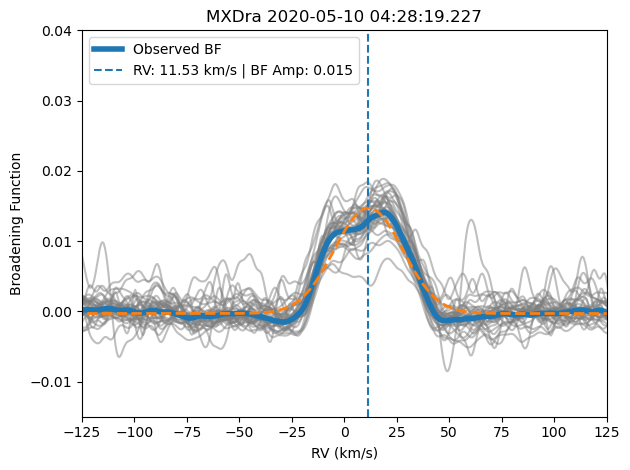

========== End of Run ==========

File 2
C:\Users\Jonah\Astro\Stars\DATA\stars\MXDra\MXDra_2020-07-12_0_4500_4.5.p
Number of Spectral Orders: 34
BJD: 2459042.6791257365
BVCORR -6.66
  Peak 1: center = -31.95 km/s, width = 43.51 km/s
  Peak 2: center = -3.76 km/s, width = 1.12 km/s


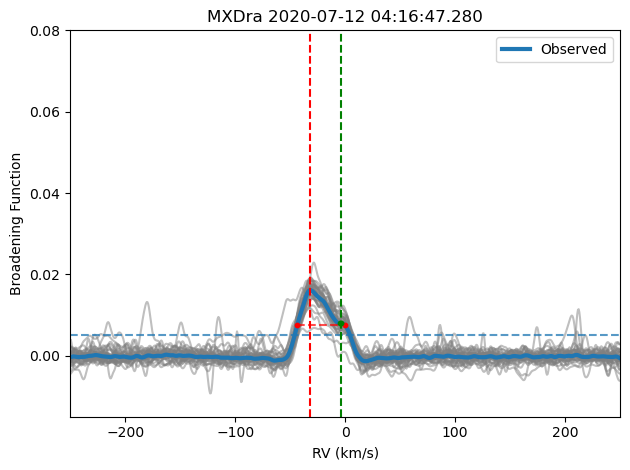

SB1
Amps: [0.01612774 0.00802529]
Centers: [-31.9510104  -3.7589424]
Widths: [43.50925746  1.11676933]
p0: [0.018, -31.951, 23.93, 0.0]

Vsini p0: [0.017740509485325833, -24.27050162065202, 23.930091600265655, 0.0]
  BVCORR: -6.66 km/s

      Results
  Primary RV (uncorrected): -24.27 + 0.26 - 0.28
  Primary RV (Barycenter Corrected): -30.93 + 0.26 - 0.28

  Primary vsini: 29.8 +/- 0.21 km/s
  
[(-30.92996244249462, 0.26218986009931555, 0.28174373838780653, 29.799978447242147, 0.21034285594213684, nan, nan, nan, nan, nan)]


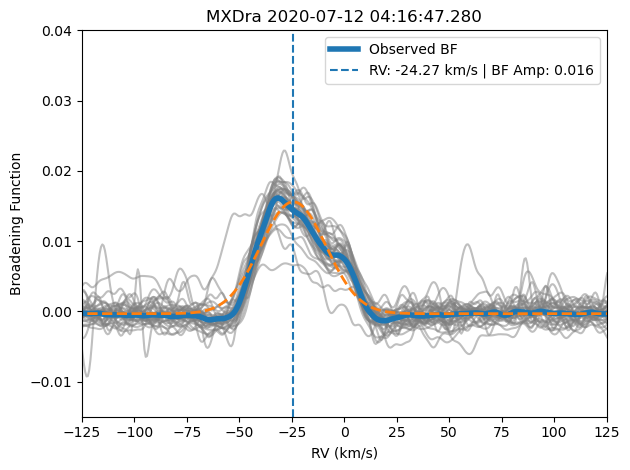

========== End of Run ==========

File 3
C:\Users\Jonah\Astro\Stars\DATA\stars\MXDra\MXDra_2021-01-31_0_4500_4.5.p
Number of Spectral Orders: 34
BJD: 2459245.9629817395
BVCORR 0.903
  Peak 1: center = -15.04 km/s, width = 47.70 km/s


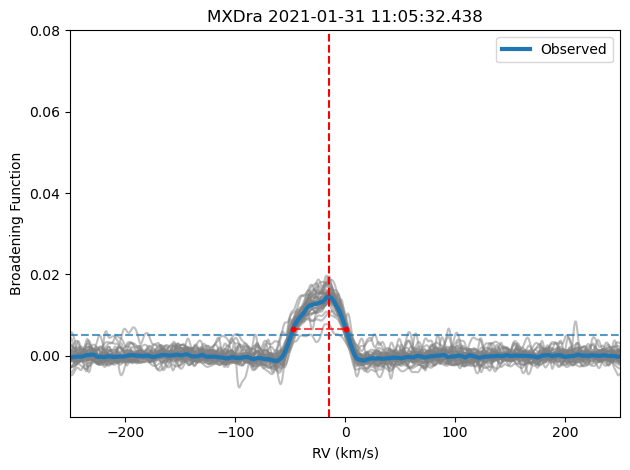

SB1
Amps: [0.01454285]
Centers: [-15.03570284]
Widths: [47.70204061]
p0: [0.016, -15.036, 26.236, 0.0]

Vsini p0: [0.015997129762410675, -22.13367141555779, 26.23612233407907, 0.0]
  BVCORR: 0.903 km/s

      Results
  Primary RV (uncorrected): -22.13 + 0.24 - 0.22
  Primary RV (Barycenter Corrected): -21.23 + 0.24 - 0.22

  Primary vsini: 30.96 +/- 0.14 km/s
  
[(-21.230738084032225, 0.2390920893327042, 0.21854722847100305, 30.960684630538424, 0.13636422814674995, nan, nan, nan, nan, nan)]


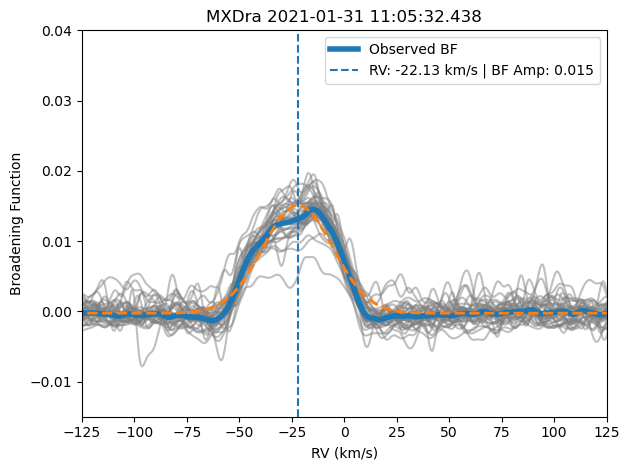

========== End of Run ==========

File 4
C:\Users\Jonah\Astro\Stars\DATA\stars\MXDra\MXDra_2021-03-30_0_4500_4.5.p
Number of Spectral Orders: 34
BJD: 2459303.8057150114
BVCORR -12.325
  Peak 1: center = -21.30 km/s, width = 48.41 km/s


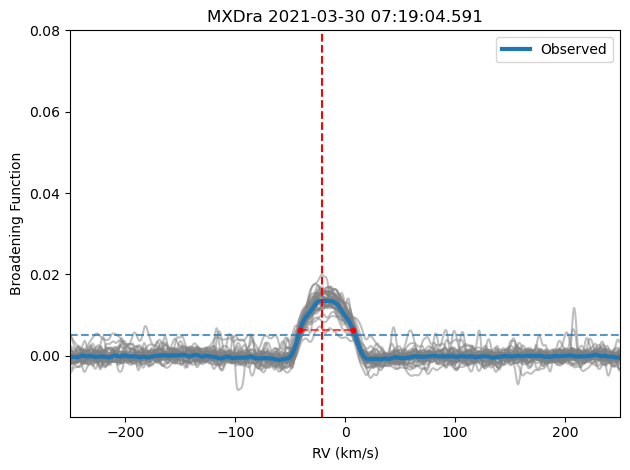

SB1
Amps: [0.01350104]
Centers: [-21.30061953]
Widths: [48.41457239]
p0: [0.015, -21.301, 26.628, 0.0]

Vsini p0: [0.014851143416583472, -16.915098749549575, 26.62801481630995, 0.0]
  BVCORR: -12.325 km/s

      Results
  Primary RV (uncorrected): -16.92 + 0.18 - 0.17
  Primary RV (Barycenter Corrected): -29.24 + 0.18 - 0.17

  Primary vsini: 30.83 +/- 0.08 km/s
  
[(-29.239403339801637, 0.1807524215915457, 0.1681014894749886, 30.82964007327941, 0.08486525146206154, nan, nan, nan, nan, nan)]


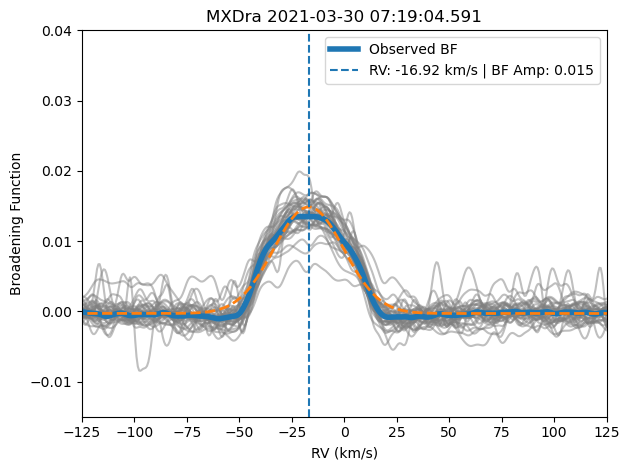

========== End of Run ==========

File 5
C:\Users\Jonah\Astro\Stars\DATA\stars\MXDra\MXDra_2021-04-01_0_4500_4.5.p
Number of Spectral Orders: 34
BJD: 2459305.8128293054
BVCORR -12.634
  Peak 1: center = 16.29 km/s, width = 48.26 km/s


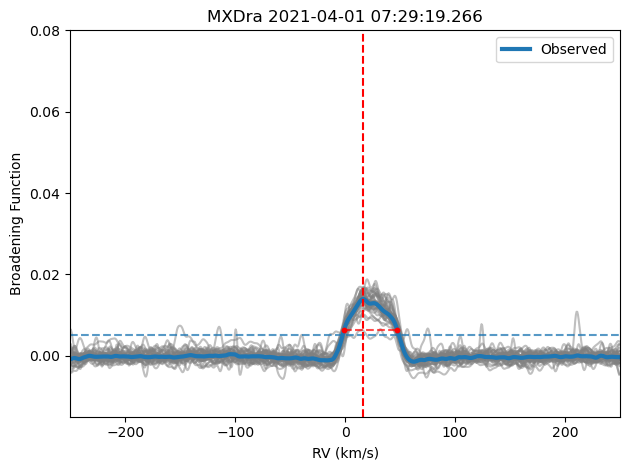

SB1
Amps: [0.01393368]
Centers: [16.28871523]
Widths: [48.25754221]
p0: [0.015, 16.289, 26.542, 0.0]

Vsini p0: [0.015327047386394954, 22.619631921035356, 26.541648216196673, 0.0]
  BVCORR: -12.634 km/s

      Results
  Primary RV (uncorrected): 22.62 + 0.26 - 0.3
  Primary RV (Barycenter Corrected): 9.98 + 0.26 - 0.3

  Primary vsini: 31.02 +/- 0.11 km/s
  
[(9.984678673447933, 0.2587242117379205, 0.2994659453274089, 31.015749904247794, 0.11320967625805957, nan, nan, nan, nan, nan)]


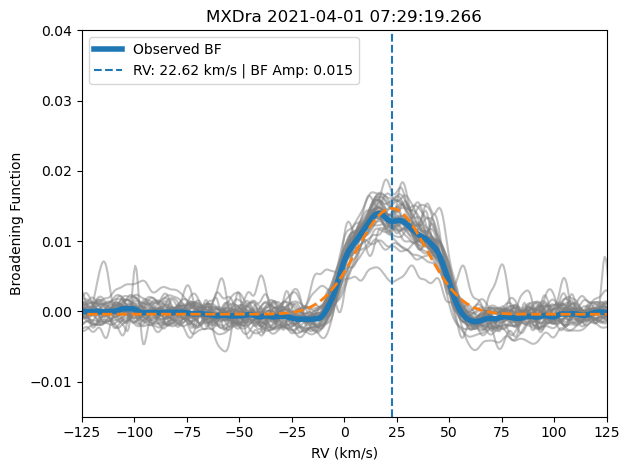

========== End of Run ==========

File 6
C:\Users\Jonah\Astro\Stars\DATA\stars\MXDra\MXDra_2021-04-23_0_4500_4.5.p
Number of Spectral Orders: 34
BJD: 2459327.787653292
BVCORR -14.874
  Peak 1: center = 29.45 km/s, width = 45.09 km/s


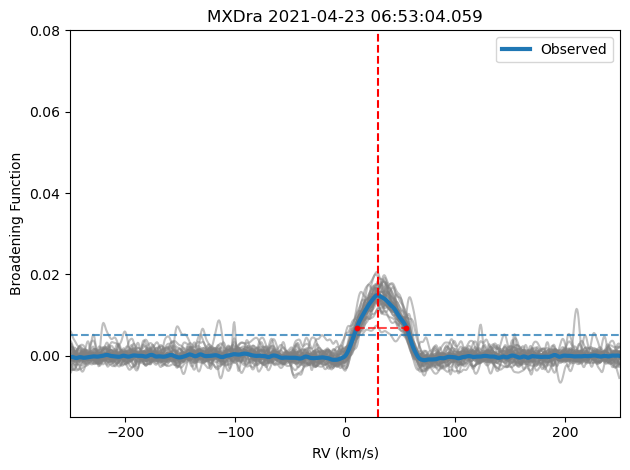

SB1
Amps: [0.01485486]
Centers: [29.44509585]
Widths: [45.09147654]
p0: [0.016, 29.445, 24.8, 0.0]

Vsini p0: [0.01634035131951742, 32.47413099760217, 24.800312097926007, 0.0]
  BVCORR: -14.874 km/s

      Results
  Primary RV (uncorrected): 32.47 + 0.23 - 0.21
  Primary RV (Barycenter Corrected): 17.6 + 0.23 - 0.21

  Primary vsini: 29.82 +/- 0.1 km/s
  
[(17.598519815517832, 0.23259562475809048, 0.21320573251657038, 29.819992609268123, 0.09672333543024461, nan, nan, nan, nan, nan)]


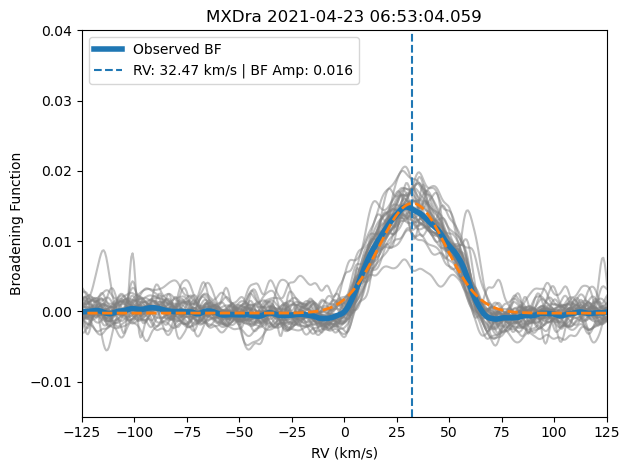

========== End of Run ==========

File 7
C:\Users\Jonah\Astro\Stars\DATA\stars\MXDra\MXDra_2021-04-24_0_4500_4.5.p
Number of Spectral Orders: 34
BJD: 2459328.775939255
BVCORR -14.917
  Peak 1: center = -8.77 km/s, width = 47.10 km/s


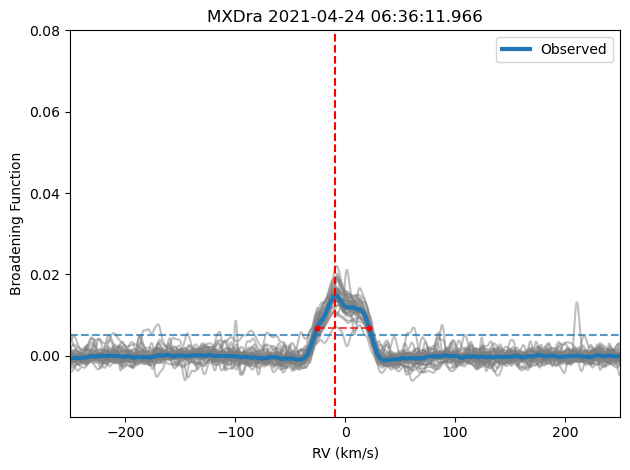

SB1
Amps: [0.01478488]
Centers: [-8.77087853]
Widths: [47.0954979]
p0: [0.016, -8.771, 25.903, 0.0]

Vsini p0: [0.016263367805424558, -2.4035927132783015, 25.90252384762999, 0.0]
  BVCORR: -14.917 km/s

      Results
  Primary RV (uncorrected): -2.4 + 0.23 - 0.17
  Primary RV (Barycenter Corrected): -17.32 + 0.23 - 0.17

  Primary vsini: 31.22 +/- 0.12 km/s
  
[(-17.320473115895165, 0.22691605769820766, 0.17477759947357985, 31.22074470860102, 0.12232200155317192, nan, nan, nan, nan, nan)]


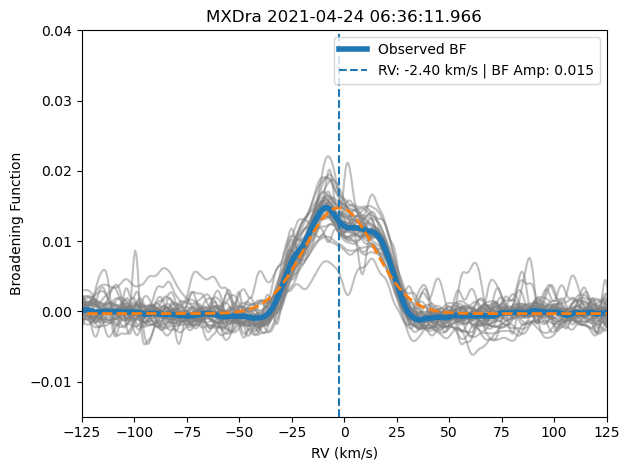

========== End of Run ==========

File 8
C:\Users\Jonah\Astro\Stars\DATA\stars\MXDra\MXDra_2021-05-30_0_4500_4.5.p
Number of Spectral Orders: 34
BJD: 2459364.692710052
BVCORR -13.985
  Peak 1: center = 63.28 km/s, width = 44.62 km/s


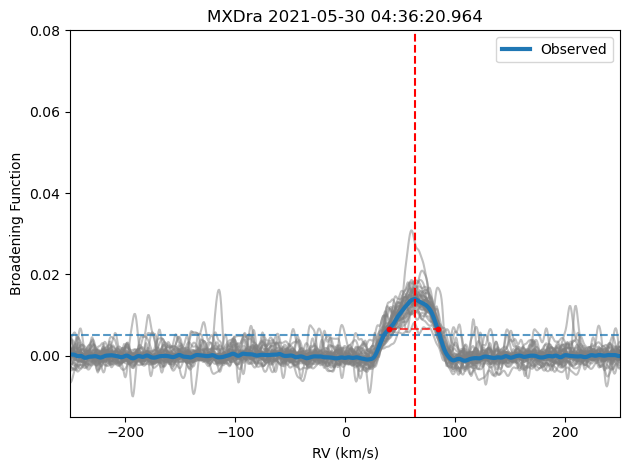

SB1
Amps: [0.0139187]
Centers: [63.27524947]
Widths: [44.62428517]
p0: [0.015, 63.275, 24.543, 0.0]

Vsini p0: [0.015310564949146678, 62.42787244614948, 24.543356840972884, 0.0]
  BVCORR: -13.985 km/s

      Results
  Primary RV (uncorrected): 62.43 + 0.21 - 0.2
  Primary RV (Barycenter Corrected): 48.44 + 0.21 - 0.2

  Primary vsini: 30.3 +/- 0.15 km/s
  
[(48.43996025207601, 0.21301485250527463, 0.20386583088938437, 30.30479975228133, 0.147792961302483, nan, nan, nan, nan, nan)]


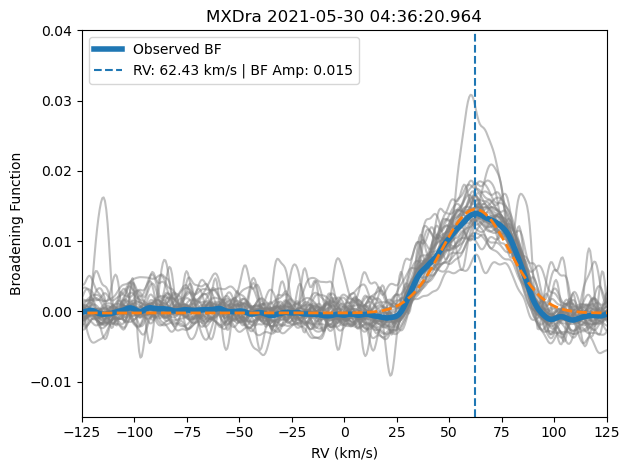

========== End of Run ==========

File 9
C:\Users\Jonah\Astro\Stars\DATA\stars\MXDra\MXDra_2021-07-09_0_4500_4.5.p
Number of Spectral Orders: 34
BJD: 2459404.6221216903
BVCORR -7.372
  Peak 1: center = 20.67 km/s, width = 46.91 km/s


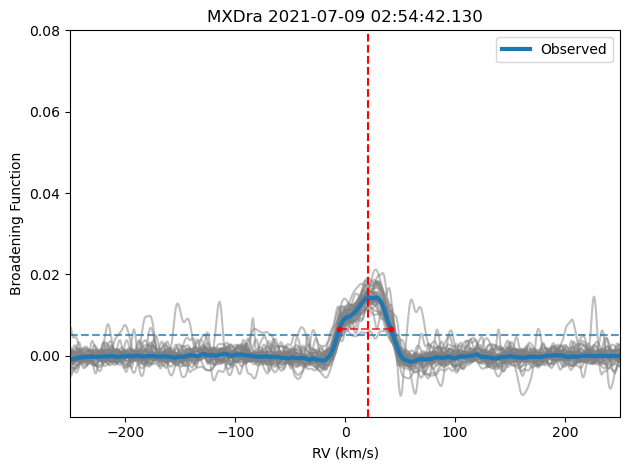

SB1
Amps: [0.0143212]
Centers: [20.67409141]
Widths: [46.91144822]
p0: [0.016, 20.674, 25.801, 0.0]

Vsini p0: [0.015753324196168043, 19.967594103827473, 25.801296521442485, 0.0]
  BVCORR: -7.372 km/s

      Results
  Primary RV (uncorrected): 19.97 + 0.21 - 0.22
  Primary RV (Barycenter Corrected): 12.6 + 0.21 - 0.22

  Primary vsini: 30.32 +/- 0.16 km/s
  
[(12.59510309378458, 0.21434377058385934, 0.21880477118106256, 30.317876085262967, 0.15654236154779552, nan, nan, nan, nan, nan)]


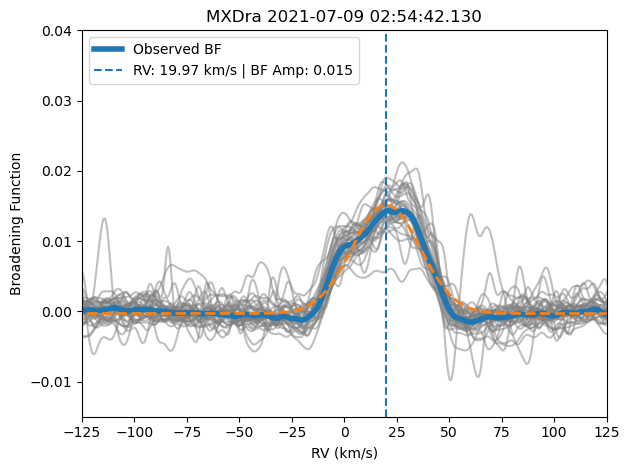

========== End of Run ==========

========== End of Line ==========


In [41]:
SB1_indexes, SB2_indexes = [], []
results = []


p0s = []
for k in range(len(txtfiles)):
    print("File", k+1)
    filename = txtfiles[k]    #re-initialize a new filename
    filepath= os.path.join(path,filename)
    print(filepath)
    #read in the pickle and smooth the broadening function to instrumental resolution
    
    tar,tar_spec = pkl.load(open(filepath,'rb'))
    tar_spec = saph.bf.analysis(tar,tar_spec,R =R_coude)

    ''' 
    # 1) Is the template name the same each epoch?
    print("Example temp_name:", tar_spec[tar[0]].get("temp_name", None))
    
    # 2) Is vflux_temp identical-ish each epoch? (quick hash)
    import numpy as np
    vf = tar_spec[tar[0]]["vflux_temp"]
    print("vflux_temp mean/std:", np.mean(vf), np.std(vf))
    print("vflux_temp first 5:", vf[:5])
    '''

    
    print(f'Number of Spectral Orders: {len(tar)}')

    ##############
    print(f"BJD: {BJD[k]}")
    print(f"BVCORR {BVCORR[k]}")
    time_title = Time(BJD[k], format='jd', scale='tdb')
    date_title = time_title.utc.iso
    # filesystem-safe date string
    #date_str = time_title.utc.strftime("%Y-%m-%d")
    # OR, if you want time resolution:
    date_str = time_title.utc.strftime("%Y-%m-%dT%H-%M-%S")

    
    # RV creation
    vel,bf,bf_sterr,bf_wstd = saph.bf.weight_combine(tar,tar_spec,vel_gt_lt=(+150,-150))
    ##############

    
    # plot everything
    #fig, ax = plt.subplots(figsize=(8,4))
    fig,ax = plt.subplots(1)
    for i in range(tar.size):
        ax.plot(tar_spec[tar[i]]['vel'],
                tar_spec[tar[i]]['bf_smooth'],
                color="grey", alpha=0.5)

    ax.plot(vel, bf, label="Observed", lw=3)

    # define colors: largest peak = red, second = green
    center_colors = ['red', 'green']
    width_alphas  = [0.5, 0.5]  # widths will be same color but semi‐transparent





    ax.set_title(f"{star} {date_title}")
    ax.set_xlabel('RV (km/s)')
    ax.set_ylabel('Broadening Function')
    #ax.axvline(rvsmean, ls='--')
    plt.xlim(-250, 250)
    plt.ylim(-0.015, 0.08)
    #ax.axhline(0.01, ls = '--')
    ax.axhline(0.005, ls = '--', alpha = 0.75)
    plt.legend()

    from scipy.signal import find_peaks, peak_widths
    peaks, props = find_peaks(bf, prominence=0.00001, distance = 25, height = 0.005) #These values work for most systems, may have to adjust
    num_peaks = len(peaks)

    
    # Isolate the two highest‐amplitude peaks
    peak_heights = bf[peaks]
    n_to_plot    = min(num_peaks, 2)
    top_idxs     = np.argsort(peak_heights)[::-1][:n_to_plot]
    two_peaks    = peaks[top_idxs]

    # get half‐max widths for those peaks
    widths, height_at_half, left_ips, right_ips = peak_widths(bf, two_peaks, rel_height=0.5)
    if num_peaks == 0:
        print("  no peaks found")
        plt.show()
        continue

    
        
    for i, peak in enumerate(two_peaks):
        c = center_colors[i]
        # 1) vertical line at the peak center
        ax.axvline(vel[peak], ls="--", color=c)
    
        # 2) left/right velocities for half‐max
        v_low  = np.interp(left_ips[i],  np.arange(len(vel)), vel)
        v_high = np.interp(right_ips[i], np.arange(len(vel)), vel)
    
        # 3) horizontal half‐max line
        ax.hlines(y=height_at_half[i],
                  xmin=v_low, xmax=v_high,
                  colors=c, linestyles='--', alpha=0.7)
    
        # 4a) tiny vertical bars at the two ends:
        #ax.plot([v_low, v_high],
        #        [height_at_half[i], height_at_half[i]],
        #        marker='|', linestyle='', markersize=10, color=c)
    
        # 4b) simple dots instead:
        ax.scatter([v_low, v_high],
                    [height_at_half[i]]*2,
                    marker='o', s = 10, color=c, zorder = 10)
        print(f"  Peak {i+1}: center = {vel[peak]:.2f} km/s, width = {(v_high - v_low):.2f} km/s")

    plt.tight_layout()
    plt.show()
    plt.close()



    from Fit_SB1_asym import Run_SB1
    from Fit_SB2_asym import Run_SB2
    


    
    #if Force_SB1 == True or len(guesses[k])<6:    #absolute force of an SB1 fit, comment out the next line if this is used.
    if num_peaks < 2 or Force_SB1 == True or widths[1] < 0:
        print("SB1")
        SB1_indexes.append(k)

        idx = np.arange(len(vel))
        left_vels  = np.interp(left_ips,  idx, vel)
        right_vels = np.interp(right_ips, idx, vel)
        # now pull out the three vectors:
        peak_amps   = bf[two_peaks]               # amplitudes at the two peaks
        peak_rvs    = vel[two_peaks]              # RV centerlines
        peak_widths = right_vels - left_vels      # width (km/s)
        
        print("Amps:",   peak_amps)
        print("Centers:",peak_rvs)
        print("Widths:", peak_widths)

        if manual == True:
            p0 = guesses[k]
        else:
            p0 = [peak_amps[0]*1.1, peak_rvs[0], peak_widths[0]*1.1/2,
                  0.0]
        
        print(f"p0: {[round(x, 3) for x in p0]}")
        output = Run_SB1(tar,tar_spec, vel,bf,bf_sterr,bf_wstd, 
                filename, star, date_title, BVCORR[k], p0)
        results.append((BJD[k], *output))
        print([output])





    
    else:
        print("SB2")
        SB2_indexes.append(k)

        idx = np.arange(len(vel))
        left_vels  = np.interp(left_ips,  idx, vel)
        right_vels = np.interp(right_ips, idx, vel)
        # now pull out the three vectors:
        peak_amps   = bf[two_peaks]               # amplitudes at the two peaks
        peak_rvs    = vel[two_peaks]              # RV centerlines
        peak_widths = right_vels - left_vels      # width (km/s)
        
        print("Amps:",   peak_amps)
        print("Centers:",peak_rvs)
        print("Widths:", peak_widths)
        if manual == True:
            p0 = guesses[k]
        #elif k == len(txtfiles) - 1:
        #    p0 = [ 0.014269385896399384, -74.66480800670901, 13.186207343707627, 0.015669322856370602, 68.224514112524, 33.489414447793436, 0.0001]
        else:
            p0 = [peak_amps[0]*1.1, peak_rvs[0], peak_widths[0]*1.1/2,
             peak_amps[1]*1.075, peak_rvs[1], peak_widths[1]*1.05/2,
              0.0]
        print(f"p0: {[round(x, 3) for x in p0]}")
        output = Run_SB2(tar,tar_spec, vel,bf,bf_sterr,bf_wstd, 
                        filename, star, date_title, BVCORR[k], p0)
        results.append((BJD[k], *output))
        print(output)

    #if k == 2:
    #    plt.savefig(f"{star}_{k}", dpi = 300)


    #plt.ylim(-0.015, 0.08)
    plt.xlim(-125, 125)
    plt.ylim(-0.015, 0.04)
    plt.xticks(np.arange(-125, 126, 25))
    #if k == 5:
    #    plt.xlim(-175, 175)
    #    plt.xticks(np.arange(-175, 176, 25))
    plt.tight_layout()
    
    outfile = outdir / f"{star}_{date_str}.png"
    plt.savefig(outfile, dpi=300, bbox_inches="tight")   #Save BF profiles
    
    plt.show()
    plt.close()

    p0s.append(p0)     




    
    print("========== End of Run ==========\n")

print("========== End of Line ==========")


In [407]:
print("p0 guesses:")   #prints all p0 guesses for review, can copy this for redoing manual guessing per-iteration
for p0 in p0s:
    print(f"{[round(x, 3) for x in p0]},")



p0 guesses:
[0.011, 66.776, 29.572, 0.01, 40.306, 1.46, 0.0],
[0.011, 16.835, 29.572, 0.01, 42.871, 1.46, 0.0],


In [408]:
print("BJD | RV1 | RV1_hi | RV1_lo | Vsini1 | Vsini1_err | RV2 | RV2_hi | RV2_lo | Vsini2 | Vsini2_err")
print("--"*45)


for i, tup in enumerate(results):
    formatted = ", ".join(f"{x:.4f}" for x in tup)
    if i < len(results) - 1:
        print(f"[{formatted}],")
    else:
        print(f"[{formatted}]")


BJD | RV1 | RV1_hi | RV1_lo | Vsini1 | Vsini1_err | RV2 | RV2_hi | RV2_lo | Vsini2 | Vsini2_err
------------------------------------------------------------------------------------------
[2459174.9894, 89.0869, 0.2056, 0.2651, 34.8564, 2.8917, 62.6151, 0.2788, 0.3499, -44.8312, 0.1181],
[2459305.6867, -12.8634, 0.6642, 0.6721, 463.1490, inf, 13.1697, 0.4741, 0.5609, 35.1331, inf]


Primary
  Semi-Amplitude  : 50.975 km/s
  Mean            : 38.112 km/s
  STD             : 50.975 km/s
Primary Error Bars
  RV1_hi max      : 0.664 km/s
  RV1_hi mean     : 0.435 km/s
  RV1_lo max      : 0.672 km/s
  RV1_lo mean     : 0.469 km/s

Vsini1
  Mean            : 249.003
  Error mean      : inf
  Error max       : inf

Secondary
  Semi-Amplitude  : 24.723 km/s
  Mean            : 37.892 km/s
  STD             : 24.723 km/s
Secondary Error Bars
  RV2_hi max      : 0.474 km/s
  RV2_hi mean     : 0.376 km/s
  RV2_lo max      : 0.561 km/s
  RV2_lo mean     : 0.455 km/s

Vsini2
  Mean            : -4.849
  Error mean      : inf
  Error max       : inf



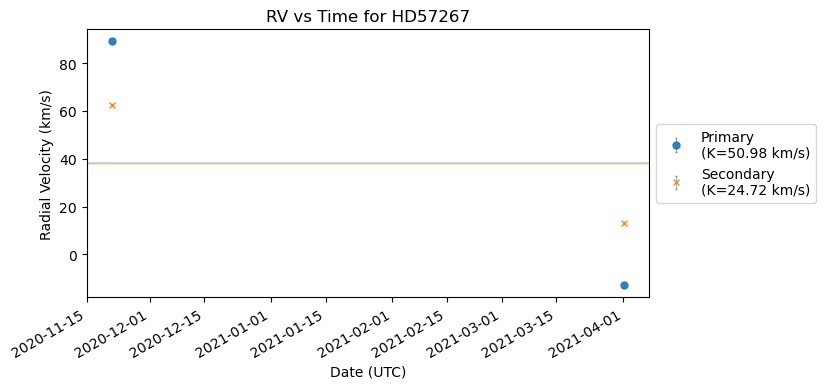

Number of files used: 2


In [409]:

#re-import in case we want to manually run results, for example:
#results = np.array([
#        [RV data format from {starname}_RV.txt],
#        [RV data format from {starname}_RV.txt],
#])

#Also, see example at the bottom of this file for UCAC2 28842571

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from astropy.time import Time


#=========================================================
#RV, Vsini stats and plot for this star

# setup array/data tables
data     = np.array(results)
bjd      = data[:,0]
rv1      = data[:,1]
rv1_hi   = data[:,2]
rv1_lo   = data[:,3]
vsini1   = data[:,4]
vsini1_er= data[:,5]
rv2      = data[:,6]
rv2_hi   = data[:,7]
rv2_lo   = data[:,8]
vsini2   = data[:,9]
vsini2_er= data[:,10]

# PRIMARY RV stats
primary_amp    = (np.nanmax(rv1) - np.nanmin(rv1)) / 2
primary_mean   = np.nanmean(rv1)
primary_std    = np.nanstd(rv1)
rv1_hi_max     = np.nanmax(rv1_hi)
rv1_hi_mean    = np.nanmean(rv1_hi)
rv1_lo_max     = np.nanmax(rv1_lo)
rv1_lo_mean    = np.nanmean(rv1_lo)

print(f"""Primary
  Semi-Amplitude  : {primary_amp:.3f} km/s
  Mean            : {primary_mean:.3f} km/s
  STD             : {primary_std:.3f} km/s
Primary Error Bars
  RV1_hi max      : {rv1_hi_max:.3f} km/s
  RV1_hi mean     : {rv1_hi_mean:.3f} km/s
  RV1_lo max      : {rv1_lo_max:.3f} km/s
  RV1_lo mean     : {rv1_lo_mean:.3f} km/s
""")

# Vsini1 stats
vs1_mean      = np.nanmean(vsini1)
vs1_err_mean  = np.nanmean(vsini1_er)
vs1_err_max   = np.nanmax(vsini1_er)
print(f"""Vsini1
  Mean            : {vs1_mean:.3f}
  Error mean      : {vs1_err_mean:.3f}
  Error max       : {vs1_err_max:.3f}
""")

# Mask for valid secondary points
mask2 = ~np.isnan(rv2)

# Convert BJD → datetime
t     = Time(bjd, format='jd', scale='tdb')
dates = t.to_datetime()

fig, ax = plt.subplots(figsize=(7,4))

# Plot primary
ax.errorbar(dates, rv1,
            yerr=[rv1_lo, rv1_hi],
            fmt='o',
            label=f"Primary\n(K={primary_amp:.2f} km/s)",
            ecolor='grey', capsize=1, elinewidth=0.5,
            ms=5, alpha=0.9)

# Plot + compute secondary if we have any real points
if mask2.any():
    rv2_v      = rv2[mask2]
    rv2_lo_v   = rv2_lo[mask2]
    rv2_hi_v   = rv2_hi[mask2]
    dates_v    = dates[mask2]

    secondary_amp   = (np.nanmax(rv2_v) - np.nanmin(rv2_v)) / 2
    secondary_mean  = np.nanmean(rv2_v)
    secondary_std   = np.nanstd(rv2_v)
    rv2_hi_max      = np.nanmax(rv2_hi_v)
    rv2_hi_mean     = np.nanmean(rv2_hi_v)
    rv2_lo_max      = np.nanmax(rv2_lo_v)
    rv2_lo_mean     = np.nanmean(rv2_lo_v)

    print(f"""Secondary
  Semi-Amplitude  : {secondary_amp:.3f} km/s
  Mean            : {secondary_mean:.3f} km/s
  STD             : {secondary_std:.3f} km/s
Secondary Error Bars
  RV2_hi max      : {rv2_hi_max:.3f} km/s
  RV2_hi mean     : {rv2_hi_mean:.3f} km/s
  RV2_lo max      : {rv2_lo_max:.3f} km/s
  RV2_lo mean     : {rv2_lo_mean:.3f} km/s
""")

    # Vsini2 stats
    vs2 = vsini2[mask2]
    vs2_er = vsini2_er[mask2]
    vs2_mean     = np.nanmean(vs2)
    vs2_err_mean = np.nanmean(vs2_er)
    vs2_err_max  = np.nanmax(vs2_er)
    print(f"""Vsini2
  Mean            : {vs2_mean:.3f}
  Error mean      : {vs2_err_mean:.3f}
  Error max       : {vs2_err_max:.3f}
""")

    ax.errorbar(dates_v, rv2_v,
                yerr=[rv2_lo_v, rv2_hi_v],
                fmt='x',
                label=f"Secondary\n(K={secondary_amp:.2f} km/s)",
                ecolor='grey', capsize=1, elinewidth=0.5,
                ms=5, alpha=0.9)
    ax.axhline(secondary_mean, alpha=0.25, color='orange')
else:
    print("Secondary RV2 is all NaN; skipping its stats, Vsini2, and plot.")

# primary mean line
ax.axhline(primary_mean, alpha=0.25)

# y‐axis padding
if mask2.any():
    y_min = min(np.nanmin(rv1), np.nanmin(rv2)) - 5
    y_max = max(np.nanmax(rv1), np.nanmax(rv2)) + 5
else:
    y_min = np.min(rv1) - 5
    y_max = np.max(rv1) + 5
ax.set_ylim(y_min, y_max)

# date formatting
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()

ax.set_xlabel('Date (UTC)')
ax.set_ylabel('Radial Velocity (km/s)')
ax.set_title('RV vs Time for ' + star)

# legend outside
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.75, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()

# ensure output folder & save
outdir = "PNGs_asym"
os.makedirs(outdir, exist_ok=True)
plt.savefig(f"{outdir}/{star}.png", dpi=135, bbox_inches='tight')   #uncomment this to save the file
plt.show()
print(f"Number of files used: {len(data)}")

In [382]:
#Save data to .txt file formats:



# 0) number of data points
n_points = len(data)

# 1) Build the summary row
row = [
    star,
    n_points,                                    # number of points
    primary_amp,                                 # RV1_amp
    rv1_hi_max,                                  # rv1_hi
    rv1_lo_max,                                  # rv1_lo
    (secondary_amp  if mask2.any() else np.nan), # RV2_amp
    (rv2_hi_max     if mask2.any() else np.nan), # rv2_hi
    (rv2_lo_max     if mask2.any() else np.nan), # rv2_lo
]

# 2) Update the global summary file in array form
summary_dir  = "summary_asym"
summary_file = os.path.join(summary_dir, "results_summary_asym.txt")
os.makedirs(summary_dir, exist_ok=True)

# Read lines
entries = {}
if os.path.exists(summary_file):
    with open(summary_file, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("Star,"):
                continue
            # line looks like: ['StarName', N, ...],
            first = line.split(",", 2)[0]           # "['StarName'"
            key   = first.lstrip("[").strip().strip("'\"")
            entries[key] = line.rstrip(",")

# Build this star's line
sec_amp_str = f"{secondary_amp:.3f}" if mask2.any() else "nan"
sec_hi_str  = f"{rv2_hi_max:.3f}"    if mask2.any() else "nan"
sec_lo_str  = f"{rv2_lo_max:.3f}"    if mask2.any() else "nan"

row_str = "['%s', %d, %.3f, %.3f, %.3f, %s, %s, %s]," % (
    star,
    n_points,
    primary_amp,
    rv1_hi_max,
    rv1_lo_max,
    sec_amp_str,
    sec_hi_str,
    sec_lo_str
)
entries[star] = row_str

# Write back sorted by star name, with header
with open(summary_file, "w") as f:
    f.write("Star, N, RV1_amp, rv1_hi, rv1_lo, RV2_amp, rv2_hi, rv2_lo\n")
    for name in sorted(entries):
        f.write(entries[name] + "\n")


# 3) Write the detailed per-star file
star_dir = os.path.join("starstxt_asym", star)
os.makedirs(star_dir, exist_ok=True)
star_file = os.path.join(star_dir, f"{star}.txt")
star_data = os.path.join(star_dir, f"{star}_RVs.txt")

with open(star_file, "w") as f:
    f.write(f"Star: {star}\n")
    f.write(f"Data length: {n_points}\n\n")

    # Primary
    f.write("Primary\n")
    f.write(f"  Amplitude       : {primary_amp:.3f} km/s\n")
    f.write(f"  Mean            : {primary_mean:.3f} km/s\n")
    f.write(f"  STD             : {primary_std:.3f} km/s\n")
    f.write("Primary Error Bars\n")
    f.write(f"  RV1_hi max      : {rv1_hi_max:.3f} km/s\n")
    f.write(f"  RV1_hi mean     : {rv1_hi_mean:.3f} km/s\n")
    f.write(f"  RV1_lo max      : {rv1_lo_max:.3f} km/s\n")
    f.write(f"  RV1_lo mean     : {rv1_lo_mean:.3f} km/s\n\n")

    # Vsini1
    f.write("Vsini1\n")
    f.write(f"  Mean            : {vs1_mean:.3f}\n")
    f.write(f"  Error mean      : {vs1_err_mean:.3f}\n")
    f.write(f"  Error max       : {vs1_err_max:.3f}\n\n")


    
    # Secondary (if present)
    if mask2.any():
        f.write("Secondary\n")
        f.write(f"  Amplitude       : {secondary_amp:.3f} km/s\n")
        f.write(f"  Mean            : {secondary_mean:.3f} km/s\n")
        f.write(f"  STD             : {secondary_std:.3f} km/s\n")
        f.write("Secondary Error Bars\n")
        f.write(f"  RV2_hi max      : {rv2_hi_max:.3f} km/s\n")
        f.write(f"  RV2_hi mean     : {rv2_hi_mean:.3f} km/s\n")
        f.write(f"  RV2_lo max      : {rv2_lo_max:.3f} km/s\n")
        f.write(f"  RV2_lo mean     : {rv2_lo_mean:.3f} km/s\n\n")
        f.write("Vsini2\n")
        f.write(f"  Mean            : {vs2_mean:.3f}\n")
        f.write(f"  Error mean      : {vs2_err_mean:.3f}\n")
        f.write(f"  Error max       : {vs2_err_max:.3f}\n")
    else:
        f.write("Secondary RV2 is all NaN; skipping its stats and Vsini2.\n\n")
        
    f.write("\nInitial Fit Parameters (p0):\n")
    for p0 in p0s:
        f.write(f"{[round(x, 3) for x in p0]}\n")



with open(star_data, "w") as f:
    for j in range(n_points):
            bjds     = bjd[j]
            rv1s      = rv1[j]
            rv1_his   = rv1_hi[j]
            rv1_los   = rv1_lo[j]
    
            if mask2.any():
                rv2s     = rv2[j]
                rv2_his  = rv2_hi[j]
                rv2_los  = rv2_lo[j]
                line = f"[{bjds:.5f}, {rv1s:.3f}, {rv1_his:.3f}, {rv1_los:.3f}, {rv2s:.3f}, {rv2_his:.3f}, {rv2_los:.3f}]"
            else:
                line = f"[{bjds:.5f}, {rv1s:.3f}, {rv1_his:.3f}, {rv1_los:.3f}, nan, nan, nan]"

            if j < n_points-1:
                f.write(line + ',\n')

            else:
                f.write(line + '\n')



# manually eliminate vsini data if necessary
bad_indices = [] #modify this by index

for k in bad_indices:
    vsini1[k]    = np.nan
    vsini1_er[k] = np.nan
    if mask2.any():
        vsini2[k]    = np.nan
        vsini2_er[k] = np.nan



# New file: per-epoch Vsini data
vsini_file = os.path.join(star_dir, f"{star}_vsini.txt")

with open(vsini_file, "w") as f:
    for j in range(n_points):
        bjds   = bjd[j]
        vs1    = vsini1[j]
        vs1_er = vsini1_er[j]

        # Apply cutoff for primary
        if vs1_er > 5:
            vs1    = np.nan
            vs1_er = np.nan

        if mask2.any():
            vs2    = vsini2[j]
            vs2_er = vsini2_er[j]

            # Apply cutoff for secondary
            if vs2_er > 5:
                vs2    = np.nan
                vs2_er = np.nan

            line = (
                f"[{bjds:.5f}, "
                f"{vs1:.3f}, {vs1_er:.3f}, "
                f"{vs2:.3f}, {vs2_er:.3f}]"
            )
        else:
            line = (
                f"[{bjds:.5f}, "
                f"{vs1:.3f}, {vs1_er:.3f}, "
                f"nan, nan]"
            )

        if j < n_points - 1:
            f.write(line + ",\n")
        else:
            f.write(line + "\n")

print("========== End of Line =========")

========== End of Line =========


In [702]:
#Manual results adjustments
#UCAC2 28842571 example, which required manual rearranging of BF peak 1 and peak 2 identification
results = [
[2459067.9228, 1.7543, 0.0695, 0.0671, 8.6124, 0.1027, -40.6678, 0.0989, 0.0797, 7.8151, 0.0789],
[2459095.8570, 39.9079, 0.0857, 0.0952, 7.8699, 0.0824, -78.4719, 0.0701, 0.0614, 8.4064, 0.0910],
[2459095.8756, 39.9900, 0.0889, 0.0882, 8.0521, np.nan, -78.5009, 0.0532, 0.0593, -0.0043, np.nan],
[2459095.8942, 40.0078, 0.0900, 0.0854, 8.3663, 0.0982, -78.4602, 0.0478, 0.0473, 7.7398, 0.0633],
[2459108.7816, -16.3875, 0.7907, 18.5443, 7.8354, np.nan, 14.5437, 0.9062, 17.7271, 0.0631, np.nan],
[2459108.8008, -35.0916, 12.3175, 0.0825, 8.0105, 0.0639, -3.1322, 7.8485, 0.1059, 7.2037, 0.0854],
[2459119.7984, -51.2200, 0.0935, 0.0880, 8.6194, 0.0642, 12.2430, 0.0718, 0.0784, 7.4499, 0.1003],
[2459119.8170, -51.1326, 0.0909, 0.0788, 8.4906, 0.1901, 12.2563, 0.0682, 0.0602, 0.1289, 533514.2332],
[2459119.8357, -51.0890, 0.0830, 0.0708, 7.5252, 1204265.9514, 12.2673, 0.0733, 0.0931, 0.3079, 0.2523],
[2459121.7752, -46.2364, 0.1040, 0.1221, 8.4845, 0.0958, 6.6792, 0.0772, 0.0736, 7.2751, 0.0727],
[2459121.7937, 6.7237, 0.0829, 0.0892, 8.6546, 0.1284, -46.0700, 0.0904, 0.1186, 7.0430, 0.0994],
[2459121.8125, 6.6914, 0.0798, 0.0909, 8.6059, 1591643.5713, -46.0196, 0.1162, 0.1092, 0.4013, 0.1693],
[2459122.8305, -40.4786, 0.0829, 0.0807, 0.1945, 919637.1632, 1.8984, 0.0551, 0.0522, 0.2392, 1468262.3134],
[2459122.8512, 1.0896, 0.1362, 0.1170, 8.3489, 0.1015, -40.5417, 0.1824, 0.1534, 7.3713, 0.1675],
[2459122.8734, -40.1044, 0.0877, 0.0928, 8.1991, 0.0830, 1.7327, 0.0724, 0.0653, 7.3824, 0.1015],
[2459123.8009, -15.4522, 0.6137, 5.9529, 6.3253, 1923631.1952, 11.4557, 0.6001, 7.7655, 0.4102, 0.2585],
[2459123.8195, -15.3954, 0.6367, 5.7852, 8.0240, 0.0679, 11.3285, 0.4547, 6.5179, 6.5076, 0.0751],
[2459123.8381, -15.0156, 0.5222, 4.4648, 6.4502, 2401974.6218, 11.5851, 0.4234, 6.2783, 0.4570, 0.2546],
[2459124.8030, -19.2934, 0.0785, 0.0724, 11.2697, 0.0760, np.nan, np.nan, np.nan, np.nan, np.nan],
[2459124.8227, -19.2935, 0.1001, 0.0931, 10.8481, 0.0837, np.nan, np.nan, np.nan, np.nan, np.nan],
[2459124.8413, -19.3516, 0.0753, 0.0781, 10.4838, 0.0602, np.nan, np.nan, np.nan, np.nan, np.nan],
[2459174.6834, -27.1278, 0.0682, 0.0707, 8.8877, 0.1983, -11.0049, 0.0848, 0.0872, 0.2702, 1045756.3653],
[2459174.7043, -27.1435, 0.0665, 0.0597, 10.5609, 0.1349, -10.8599, 0.0793, 0.0813, 0.4029, 585814.5243],
[2459174.7244, -27.4205, 0.0583, 0.0590, 9.0498, 0.1602, -10.8339, 0.0615, 0.0669, 0.3893, 954004.3598],
[2459175.6527, -30.7817, 0.1365, 0.1112, 8.0480, np.nan, -6.2118, 0.1816, 0.1294, -0.0264, np.nan],
[2459175.6711, -31.0169, 0.1259, 0.1022, 0.4544, 2004788.1763, -6.3709, 0.1770, 0.1227, 7.5350, 0.3208],
[2459175.6896, -31.3187, 0.1527, 0.1094, 0.4198, 1629143.6102, -6.4406, 0.2508, 0.1651, 7.5049, 0.2932],
[2459187.6342, -50.5727, 0.2106, 0.2108, 0.2120, 863831.9351, 13.1717, 0.1446, 0.1551, -7.2928, 0.3300],
[2459187.6529, 13.1248, 0.1391, 0.1345, 8.5213, 0.0750, -50.6065, 0.2075, 0.1982, 7.4366, 0.1291],
[2459187.6714, 13.0292, 0.1325, 0.1462, 8.5234, 1637551.6367, -50.4906, 0.1532, 0.1722, 0.5119, 0.2254],
[2459188.6361, -48.3751, 0.0846, 0.0923, 0.4474, 2501451.4716, 11.0379, 0.0909, 0.0958, 0.4811, 2345496.2292],
[2459188.6546, -48.4029, 0.0777, 0.0579, 7.7629, 908425.2109, 10.8411, 0.1036, 0.0938, 0.6214, 0.3059],
[2459452.9127, -48.9548, 0.0844, 0.0676, 8.0859, 0.1949, 10.1398, 0.1114, 0.1061, 0.4351, 2541674.0596],
[2459453.8904, -50.5279, 0.0857, 0.0898, 8.3627, 0.0680, 11.4890, 0.0828, 0.0918, 7.8815, 0.1064],
[2459490.8374, 13.8370, 0.0705, 0.0622, 8.6215, 0.0627, -52.5073, 0.0931, 0.0854, 7.6702, 0.0719]
]

In [82]:
results = np.array(results)
np.mean(results[:,2]), np.mean(results[:,3])

(0.14237048291680318, 0.14456043578564037)